# 1: Dataset download

In [1]:
import numpy as np
import cupy as cp
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

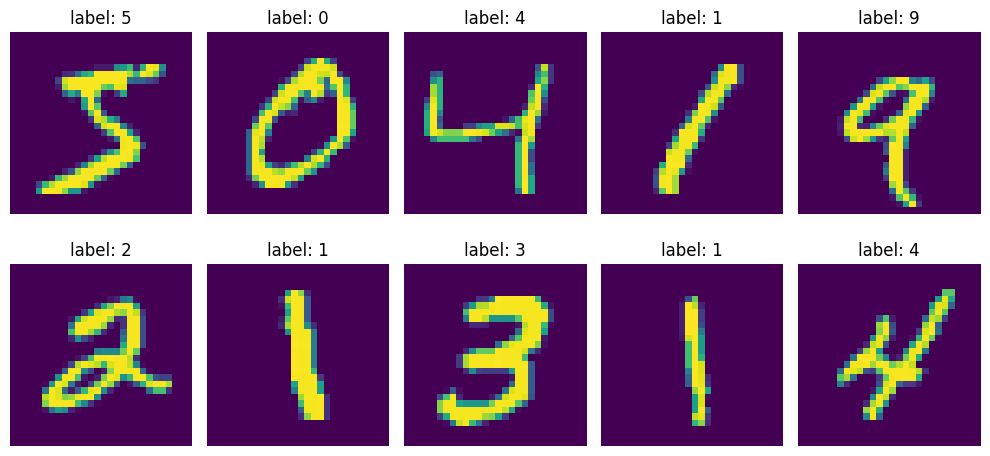

In [2]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(28, 28))
    ax.set_title(f'label: {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 0.5 Data preprocesing

In [3]:
X = cp.asarray(X.T/255)
y_one_hot = cp.zeros((70000, 10))
y = cp.asarray(y, dtype=int)
print(len(y_one_hot))
for i in range(len(y)):
    y_val = int(y[i])
    y_one_hot[i][y_val] = 1
y_one_hot = y_one_hot.T
random_idx = cp.random.permutation(X.shape[1])
X = X[:, random_idx]
y_one_hot = y_one_hot[:, random_idx]
y = y[random_idx]

70000


# 1.1 Initialize Weight

In [4]:
def initialize_weight(node_num_list):
    parameters = {}
    for l in range(1, len(node_num_list)):
        parameters['W'+str(l)] = cp.random.randn(node_num_list[l], node_num_list[l-1]) * cp.sqrt(2/node_num_list[l-1])
        parameters['b'+str(l)] = cp.zeros((node_num_list[l],1)) * cp.sqrt(2/node_num_list[l-1])
    return parameters

## 1.2 Forward_propagation

In [5]:
def relu(x):
    return cp.maximum(0, x)

def softmax(x):
    x = cp.exp(x)
    sum = cp.sum(x, axis=0)
    return x / sum

def forward_propagation(X, parameters):
    cache = {'A0': X}
    L = len(parameters) // 2
    A_prev = X

    # ReLU
    for l in range(1, L):
        W = parameters['W'+str(l)]
        b = parameters['b'+str(l)]
        Z = W @ A_prev + b
        A = relu(Z)
        A_prev = A

        cache['W'+str(l)] = W
        cache['Z'+str(l)] = Z
        cache['A'+str(l)] = A

    # softmax
    W = parameters['W'+str(L)]
    b = parameters['b'+str(L)]
    Z = W @ A_prev + b
    y_hat = softmax(Z)

    cache['W'+str(L)] = W
    cache['Z'+str(L)] = Z
    cache['A'+str(L)] = y_hat

    return y_hat, cache


## 1.3 Compute cost

In [6]:
def compute_cost(y_hat, y):
    epsilon = 1e-7
    return cp.mean(-1 * cp.log(cp.sum(y * y_hat, axis=0) + epsilon)).get()

## 1.4 Back propagation

In [7]:
def back_propagation(y_hat, y, parameters, cache):
    grads = {}
    cache = cache
    m = y_hat.shape[1]

    L = len(parameters) // 2
    grads['dZ'+str(L)] = y_hat - y
    grads['dW'+str(L)] = (grads['dZ'+str(L)] @ cache['A'+str(L-1)].T)/m
    grads['db'+str(L)] = cp.mean(grads['dZ'+str(L)], axis=1, keepdims=True)
    grads['dA'+str(L-1)] = cache['W'+str(L)].T @ grads['dZ'+str(L)]

    for l in range(L-1, 0, -1):
        grads['dZ'+str(l)] = grads['dA'+str(l)] * cp.where(cache['Z'+str(l)]>0, 1, 0)
        grads['dW'+str(l)] = (grads['dZ'+str(l)] @ cache['A'+str(l-1)].T)/m
        grads['db'+str(l)] = cp.mean(grads['dZ'+str(l)], axis=1, keepdims=True)
        grads['dA'+str(l-1)] = cache['W'+str(l)].T @ grads['dZ'+str(l)]

    return grads

# 1.5 Parameter update

In [8]:
def update_parameters(learning_rate, parameters, grads):
    L = len(parameters) // 2
    for l in range(1, L+1):
        parameters['W'+str(l)] -= learning_rate * grads['dW'+str(l)]
        parameters['b'+str(l)] -= learning_rate * grads['db'+str(l)]
    return parameters

# 1.6 Model

In [9]:
class Model(object):
    def __init__(self, node_num_list):
        self.parameters = initialize_weight(node_num_list)

    def train(self, X_train, y_train, X_val, y_val, learning_rate, epoches, display=False):
        #1. initialize_weight
        train_loss_list = []
        val_loss_list = []

        for epoch in range(epoches):
            #2. forward propagation
            y_hat, cache = forward_propagation(X_train, self.parameters)

            #3. compute cost
            cost = compute_cost(y_hat, y_train)
            train_loss_list.append(cost)

            #4. back propagation
            grads = back_propagation(y_hat, y_train, self.parameters, cache)

            #4.5 val_loss
            y_hat_val, _ = forward_propagation(X_val, self.parameters)
            val_cost = compute_cost(y_hat_val, y_val)
            val_loss_list.append(val_cost)

            #5. update parameters
            self.parameters = update_parameters(learning_rate, self.parameters, grads)
            if epoch % 100 == 0 and display:
                print(f'cost of {epoch}th epoch: {cp.round(cost, 4)}')

        return train_loss_list, val_loss_list

    def predict(self, X):
        y_hat, _ = forward_propagation(X, self.parameters)
        return cp.argmax(y_hat, axis=0)


# 1.7 Training

In [10]:
X_train = X[:, :65000]
y_train = y_one_hot[:, :65000]

X_val = X[:, 65000:70000]
y_val = y_one_hot[:, 65000:70000]

epoches = 3000
node_num_list = [784, 600, 500, 300, 100, 10]
epoches_list = np.arange(0, epoches)
model = Model(node_num_list)
train_loss_list, val_loss_list = model.train(X_train, y_train, X_val, y_val, 0.1, epoches, True)

cost of 0th epoch: 2.4098
cost of 100th epoch: 0.2731
cost of 200th epoch: 0.1942
cost of 300th epoch: 0.1535
cost of 400th epoch: 0.152
cost of 500th epoch: 0.1133
cost of 600th epoch: 0.097
cost of 700th epoch: 0.0848
cost of 800th epoch: 0.0748
cost of 900th epoch: 0.0663
cost of 1000th epoch: 0.059
cost of 1100th epoch: 0.0526
cost of 1200th epoch: 0.0471
cost of 1300th epoch: 0.0422
cost of 1400th epoch: 0.038
cost of 1500th epoch: 0.0344
cost of 1600th epoch: 0.0307
cost of 1700th epoch: 0.0276
cost of 1800th epoch: 0.0249
cost of 1900th epoch: 0.0224
cost of 2000th epoch: 0.0202
cost of 2100th epoch: 0.0182
cost of 2200th epoch: 0.0165
cost of 2300th epoch: 0.015
cost of 2400th epoch: 0.0136
cost of 2500th epoch: 0.0124
cost of 2600th epoch: 0.0113
cost of 2700th epoch: 0.0103
cost of 2800th epoch: 0.0094
cost of 2900th epoch: 0.0086


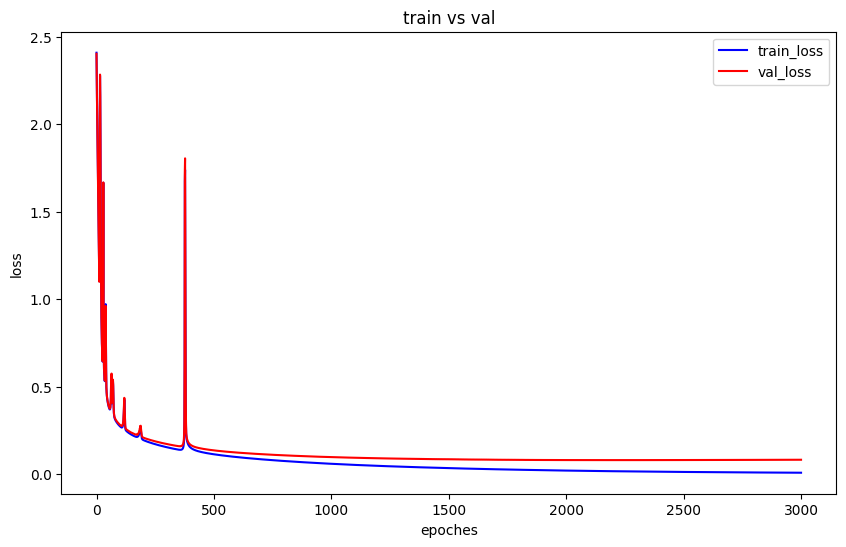

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(epoches_list, train_loss_list, color='blue', label='train_loss')
plt.plot(epoches_list, val_loss_list, color='red', label='val_loss')
plt.xlabel('epoches')
plt.ylabel('loss')
plt.title('train vs val')
plt.legend()
plt.show()

In [12]:
print('last train loss :', np.round(train_loss_list[-1], 3))
print('last val loss :', np.round(val_loss_list[-1], 3))

last train loss : 0.008
last val loss : 0.082


# 1.8 Compute accuracy

In [13]:
y_pred = model.predict(X)
print('accuracy: ', cp.round(cp.mean(y_pred == y), 3))

accuracy:  0.998
